Initial Configurations and Imports

In [1]:
import json
import logging

import numpy as np

from pathlib import Path

from src.utils.data import *
from src.utils.plots import *
from src.utils.sampling import *
from src.utils.memory_management import *
from src.utils.statistics_utils import *

# Set up logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

# Create a console handler
sh = logging.StreamHandler()
sh.setLevel(logging.INFO)
# Add the handler to the logger
logger.addHandler(sh)

from src.configs.config_parser import PathConfigParser, data_config_file, project_root

# Configs Directory
parser = PathConfigParser(str(data_config_file))
parser.load()

# Data Paths
PROCESSED_DATA_PATH = project_root / parser.get("data_paths", {}).get("processed_data")
GE_PATH = parser.get("data_paths", {}).get("brain_regions_genes_ge")
PROCESSED_DONORS_GE_PATH = PROCESSED_DATA_PATH / GE_PATH

OUTPUT_DATA = project_root / parser.get("data_paths", {}).get("output_data")

# Donors_ids
DONORS_IDS = parser.get("donors_ids")

Loading main dataframe

In [2]:
meta_donor_csv_pth = PROCESSED_DONORS_GE_PATH / Path("meta_donor.csv")
meta_donor_df = load_df_from_csv(meta_donor_csv_pth)
meta_donor_df.head(3)

meta_donor_df["gene_expression_values"]=meta_donor_df["gene_expression_values"].apply(json.loads)
logger.info(meta_donor_df["gene_expression_values"][0][0])

1.58747780630413


 Selecting Samples with sample size >=1024

In [3]:
meta_donor_df_filtered = meta_donor_df.copy()
number_of_samples_per_br_ge = get_number_of_samples_per_br_ge(meta_donor_df_filtered)
range_with_powers_of_two = [2**i for i in range(3, 11)] 
count_per_threshold= get_br_ge_count_above_sample_size(meta_donor_df_filtered, range = range_with_powers_of_two)
meta_donor_df_filtered = mask_samples_threshold(meta_donor_df_filtered, threshold=1024)
logger.info(f"DF Length after filtering matches number of samples expected: {count_per_threshold[len(count_per_threshold)-1]==len(meta_donor_df_filtered)}")

DF Length after filtering matches number of samples expected: True


Calculating Gene Mean Expression Values

In [4]:
geneid_H0 = calculate_gene_mean_expression_values(meta_donor_df)
logger.info(f"Number of Total Sample Count == {geneid_H0['total_sample_count'].sum() == get_total_number_of_samples(meta_donor_df)}")

Number of Total Sample Count == True


Calculating STD for Effect Sizes

In [5]:
df_std = meta_donor_df.copy()
std_per_gene = calculate_std_gene_id_optimized(df_std)
geneid_H0["std"] = std_per_gene["std"]
geneid_H0.head(3)

,gene_id,total_expression,total_sample_count,weighted_mean,std
0,2,16227.834876,3936,4.122926,2.693218
1,3,66283.660534,7872,8.420180,2.464688
2,6,41203.873837,13776,2.990990,2.067025


### Calculating P-values, Effect Size, T-statistic and Power for Different Sample Sizes

In [6]:
# len(meta_donor_df_filtered)
range_with_powers_of_two = [2**i for i in range(3, 11)] 
range_with_powers_of_two

[8, 16, 32, 64, 128, 256, 512, 1024]

In [7]:
# # Loop over the different sample sizes
# for sample_size in range_with_powers_of_two:
#     # Save Each statistic in a csv for ease of access later.
#     sample_size_df_stats = pd.DataFrame(meta_donor_df_filtered).drop(columns=["gene_expression_values", "sample_count"])
#     # Iterrate over the filtered samples for each sample size
#     for index, br_ge in meta_donor_df_filtered.iterrows():
#         # Getting Sample Values
#         sample = br_ge["gene_expression_values"]
        
#         if sample_size > len(sample):
#             logger.error(f"Reproducing Error, sample size available: {len(sample)} < sample_size chosen: {sample_size}")
#             raise Exception
#         else:
#             sample = sample[:sample_size]
        
#         # Getting Brain region and Gene ID
#         gene_id = br_ge["gene_id"]
#         brain_region = br_ge["brain_region"]
        
#         # Calculating Sample Stats
#         sample_mean = np.mean(sample)
#         sample_std = np.std(sample)
        
#         # Getting Control Group stats for that gene
#         control_group_mean = geneid_H0.loc[geneid_H0["gene_id"] == int(gene_id), "weighted_mean"].iloc[0]
#         control_group_std = geneid_H0.loc[geneid_H0["gene_id"] == int(gene_id), "std"].iloc[0]
#         control_group_size = geneid_H0.loc[geneid_H0["gene_id"] == int(gene_id), "total_sample_count"].iloc[0]

#         # (1) Calculating Effect Size.
#         effect_size = calculate_cohen_d(sample_mean=sample_mean, control_group_mean=control_group_mean,
#                         sample_std=sample_std, control_group_std=control_group_std,
#                         sample_length=sample_size, control_group_length=control_group_size)

#         # (2) Calculating Power
#         power = calculate_test_power(effect_size, sample_mean, control_group_mean, sample_std, sample_size)
        
#         # (3) Calculating T Statistic
#         t_obs_stat = calculate_t_statistic(sample_mean, sample_std, sample_size, control_group_mean)
        
#         # (4) Bootstraping to Calculate the p_value 
#         B = 1000
#         p_value, bootstraped_samples = calculate_bootstrap_p_value(sample, t_obs_stat, B, control_group_mean)
        
#         sample_size_df_stats.loc[index,  ["effect_size", "p-value", "power", "t_stat"]] = [effect_size, p_value, power, t_obs_stat]
    
#     write_df_to_csv(sample_size_df_stats, OUTPUT_DATA / Path(f"{sample_size}_stats.csv"))



In [8]:
# # Powers of 2 from 8 to 1024 for labeling
# labels = [2**i for i in range(3, 11)]  # 8, 16, 32, ..., 1024

# # Create a plot
# plt.figure(figsize=(10, 6))

# # Loop through each file and plot the "effect_size" column
# for idx in range_with_powers_of_two:
    
#     df = load_df_from_csv(OUTPUT_DATA/ Path(f"{idx}_stats.csv"))
    
#     # Extract the 'effect_size' column
#     effect_size = df['effect_size']
    
#     # Plot the 'effect_size' column for each file with different labels
#     plt.plot(effect_size, label=f'{idx}', marker='o')

# # Set plot labels and title
# plt.xlabel('Index')
# plt.ylabel('Effect Size')
# plt.title('Effect Size Comparison Across Files')
# plt.legend(title='Power of 2 Labels')

# # Show the plot
# plt.tight_layout()
# plt.show()

In [10]:
meta_donor_df_filtered.head(2)

,brain_region,gene_id,gene_expression_values,sample_count
1692,4012,2541,"[3.4665720939923, 6.68308773283322, 8.86049794...",1232
30067,4013,1259,"[3.98176589692518, 7.197362738781371, 7.085808...",1691


In [11]:
meta_donor_df_filtered = meta_donor_df_filtered.reset_index(drop=True)
print(meta_donor_df_filtered.index.duplicated())


[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False Fa

In [12]:
# Loop over the different sample sizes

# # Save Each statistic in a csv for ease of access later.
# sample_size_df_stats = pd.DataFrame(meta_donor_df_filtered).drop(columns=["gene_expression_values", "sample_count"])

# Iterrate over the filtered samples for each sample size

stats_df = pd.DataFrame(meta_donor_df_filtered).drop(columns=["gene_expression_values", "sample_count"])
for index, br_ge in meta_donor_df_filtered.iterrows():
    logger.info(f"index:  {index}")
    effect_sizes, p_values, powers, t_obs_stats =[], [], [], []
    for sample_size in range_with_powers_of_two:
        # Getting Sample Values
        sample = br_ge["gene_expression_values"]
        
        if sample_size > len(sample):
            logger.error(f"Reproducing Error, sample size available: {len(sample)} < sample_size chosen: {sample_size}")
            raise Exception
        else:
            sample = sample[:sample_size]
        
        # logger.info(f"SAMPLE SIZE: { sample_size}")
        # logger.info(f"LEN SAMPLE: {len(sample)}")
        if len(sample) == 1:
            raise ValueError
        
        # Getting Brain region and Gene ID
        gene_id = br_ge["gene_id"]
        brain_region = br_ge["brain_region"]
        
        # Calculating Sample Stats
        sample_mean = np.mean(sample)
        sample_std = np.std(sample)
        
        # Getting Control Group stats for that gene
        control_group_mean = geneid_H0.loc[geneid_H0["gene_id"] == int(gene_id), "weighted_mean"].iloc[0]
        control_group_std = geneid_H0.loc[geneid_H0["gene_id"] == int(gene_id), "std"].iloc[0]
        control_group_size = geneid_H0.loc[geneid_H0["gene_id"] == int(gene_id), "total_sample_count"].iloc[0]

        # (1) Calculating Effect Size.
        effect_size = calculate_cohen_d(sample_mean=sample_mean, control_group_mean=control_group_mean,
                        sample_std=sample_std, control_group_std=control_group_std,
                        sample_length=sample_size, control_group_length=control_group_size)

        # (2) Calculating Power
        power = calculate_test_power(effect_size, sample_mean, control_group_mean, sample_std, sample_size)
        
        # (3) Calculating T Statistic
        t_obs_stat = calculate_t_statistic(sample_mean, sample_std, sample_size, control_group_mean)
        
        # (4) Bootstraping to Calculate the p_value 
        B = 1000
        p_value, bootstraped_samples = calculate_bootstrap_p_value(sample, t_obs_stat, B, control_group_mean)
        
        stats_df.loc[index, f"effect_size_{sample_size}"] = effect_size
        stats_df.loc[index, f"p-value_{sample_size}"] = p_value
        stats_df.loc[index, f"power_{sample_size}"] = power
        stats_df.loc[index, f"t_stat_{sample_size}"] = t_obs_stat
    
    
write_df_to_csv(stats_df, OUTPUT_DATA / Path(f"df_stats.csv"))



index:  0
index:  1
index:  2
index:  3
index:  4
index:  5
index:  6
index:  7
index:  8
index:  9
index:  10
index:  11
index:  12
index:  13
index:  14
index:  15
index:  16
index:  17
index:  18
index:  19
index:  20
index:  21
index:  22
/home/affectiva/git/Gene-Expression-Analysis/src/utils/statistics_utils.py:102: RuntimeWarning: divide by zero encountered in scalar divide
  t_stat = (sample_mean - population_mean) / (sample_std / (sample_size ** 0.5))
index:  23
index:  24
index:  25
index:  26
index:  27
index:  28
index:  29
index:  30
index:  31
index:  32
index:  33
index:  34
index:  35
index:  36
index:  37
index:  38
index:  39
index:  40
index:  41
index:  42
index:  43
index:  44
index:  45
index:  46
index:  47
index:  48
index:  49
index:  50
index:  51
index:  52
index:  53
index:  54
index:  55
index:  56
index:  57
index:  58
index:  59
index:  60
index:  61
index:  62
index:  63
index:  64
index:  65
index:  66
index:  67
index:  68
index:  69
index:  70
index:  

In [19]:
stats_df.head(3)

,brain_region,gene_id,effect_size_8,p-value_8,power_8,t_stat_8,effect_size_16,p-value_16,power_16,t_stat_16,...,power_256,t_stat_256,effect_size_512,p-value_512,power_512,t_stat_512,effect_size_1024,p-value_1024,power_1024,t_stat_1024
0,4012,2541,0.660989,0.526,0.516438,2.047662,0.191472,0.540,0.180571,0.680607,...,0.981044,3.933377,0.160568,0.508,0.976349,4.053816,0.248509,0.503,1.000000,9.128628
1,4013,1259,0.245027,0.547,0.154585,1.629629,-0.261226,0.490,0.004090,-1.308766,...,0.961376,4.050320,0.129349,0.512,0.899395,3.445528,0.073466,0.496,0.759442,2.823152
2,4013,2541,0.647047,0.518,0.502355,2.026755,0.225726,0.541,0.216991,0.820358,...,0.999331,5.377931,0.284881,0.499,1.000000,7.349173,0.226579,0.503,1.000000,8.476261


No handles with labels found to put in legend.


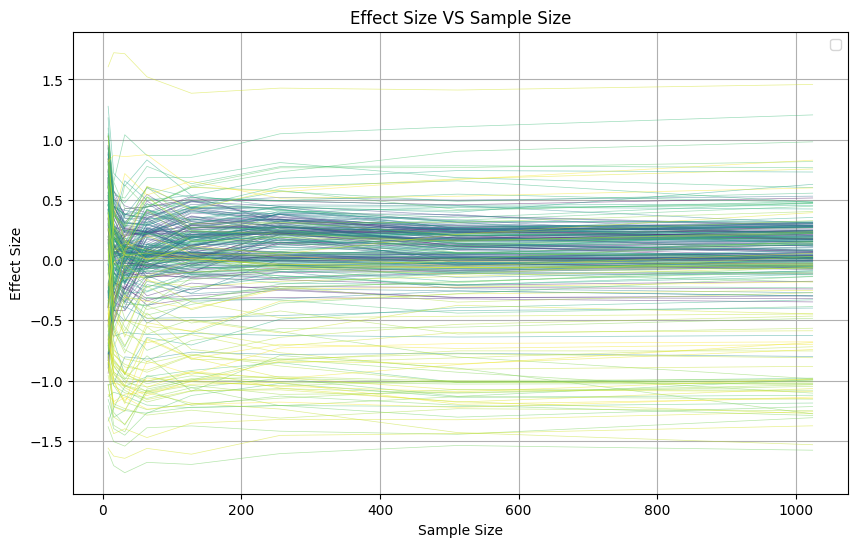

In [54]:
# Plotting each of the 8 columns
from matplotlib.cm import viridis

columns = [f"effect_size_{sample_size}" for sample_size in range_with_powers_of_two]

effect_size_df = stats_df[columns]
transpose_effect_size_df = effect_size_df.T.reset_index(drop=True)

plt.figure(figsize=(10, 6))
colors = viridis(np.linspace(0, 1, len(transpose_effect_size_df.columns)))
idx = 0
for column in transpose_effect_size_df:  # iterate over column names
    plt.plot(range_with_powers_of_two, transpose_effect_size_df[column].values, color=colors[idx], linewidth=0.5, alpha=0.5)
    idx+=1


# Adding labels and title
plt.xlabel("Sample Size")
plt.ylabel("Effect Size")
plt.title("Effect Size VS Sample Size")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

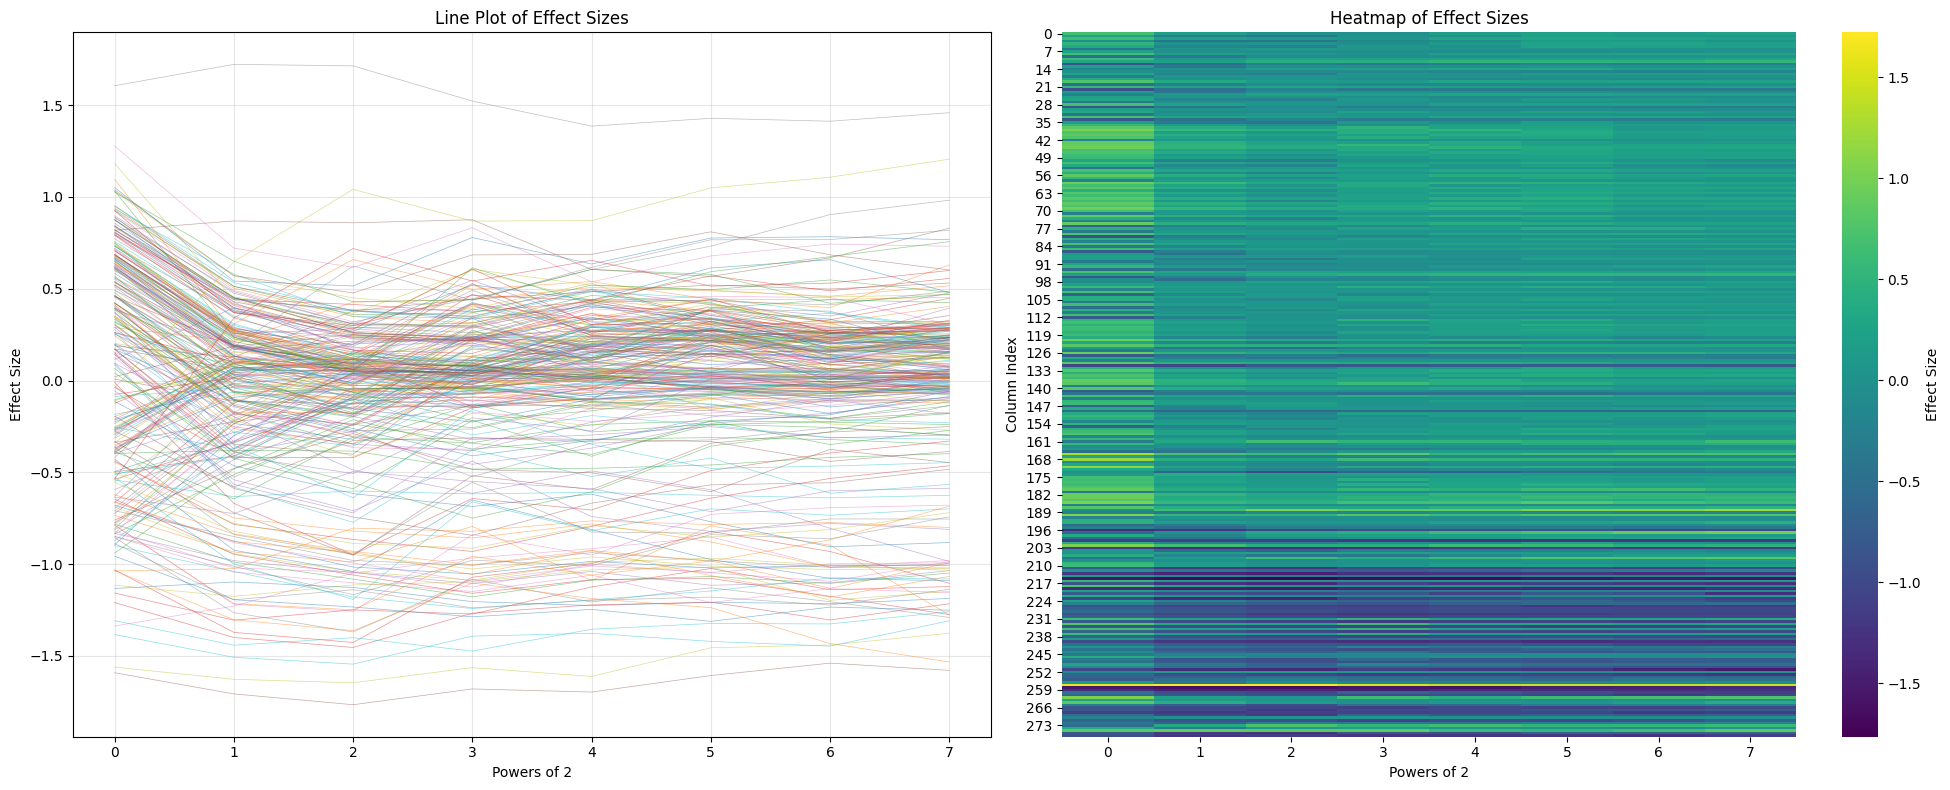

In [50]:
import seaborn as sns

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Line plot on the left
for column in transpose_effect_size_df:
    values = transpose_effect_size_df[column].values  # get values as numpy array
    # plt.plot(transpose_effect_size_df.index.values, values, color=colors[idx], linewidth=0.5, alpha=0.5)
    ax1.plot(transpose_effect_size_df.index.values, values, linewidth=0.5, alpha=0.5)
ax1.set_xlabel("Powers of 2")
ax1.set_ylabel("Effect Size")
ax1.set_title("Line Plot of Effect Sizes")
ax1.grid(True, alpha=0.3)

# Heatmap on the right
sns.heatmap(transpose_effect_size_df.T, # Transpose the data for better visualization
            cmap='viridis',  # You can change the colormap (e.g., 'coolwarm', 'RdBu_r', 'YlOrRd')
            cbar_kws={'label': 'Effect Size'},
            ax=ax2)
ax2.set_xlabel("Powers of 2")
ax2.set_ylabel("Column Index")
ax2.set_title("Heatmap of Effect Sizes")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()